In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import math
import random
import os  
# import cv2
from PIL import Image
from torch import Tensor

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models, utils

%matplotlib inline
%load_ext autoreload
%autoreload 2

import torch.utils.data as Data
import matplotlib.pyplot as plt
import pandas as pd
import warnings#而这两句则是为了将程序运行时的警告显示去除用的
warnings.filterwarnings("ignore")
import torchvision
import sys

from collections import defaultdict
from tqdm import tqdm

def is_nan(nan):
    return not float('-inf') < nan < float('inf')
d_model = 4  # Embedding Size
max_len=1830
n_shot=5

In [4]:
import os
import numpy as np

def load_npy_data(folder_path, reshape_size=3660, max_samples=50):
    """
    从指定目录加载.npy文件并处理数据
    
    Args:
        folder_path (str): 存放.npy文件的目录路径
        reshape_size (int): 数据重塑后的维度，默认3660
        max_samples (int): 保留的最大样本数，默认50
    
    Returns:
        np.array: 处理后的数组，形状为 (min(文件数, max_samples), reshape_size)
    
    Raises:
        FileNotFoundError: 目录不存在时抛出
        ValueError: 目录下无有效.npy文件时抛出
    """
    # 检查目录是否存在
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"目录不存在: {folder_path}")
    
    # 筛选有效.npy文件（排除隐藏文件）
    npy_files = [
        file for file in os.listdir(folder_path)
        if file.endswith('.npy') and not file.startswith('.')
    ]
    
    # 无有效文件时抛出异常
    if not npy_files:
        raise ValueError(f"目录 {folder_path} 下未找到有效.npy文件")
    
    # 加载并处理数据
    data = []
    for file_name in npy_files:
        file_path = os.path.join(folder_path, file_name)
        try:
            # 加载npy文件
            x = np.load(file_path, allow_pickle=True)
            # 重塑为指定维度
            x_reshaped = x.reshape(reshape_size)
            data.append(x_reshaped)
        except Exception as e:
            print(f"加载文件 {file_path} 失败: {e}")
            continue
    
    # 转换为数组并只保留前max_samples个样本
    data_array = np.array(data)
    print(f"{folder_path} 数据形状: {data_array.shape}")
    return data_array

# 定义要处理的目录列表
# target_dirs = [f'data/{i}' for i in range(16, 48)]
nnn = 32
target_dirs = [f'data/{i}' for i in range(16, 16+nnn)]

# 存储所有目录的处理结果（键：目录名，值：数据数组）
all_data = {}

# 遍历目录并加载数据
for dir_path in target_dirs:
    try:
        all_data[dir_path] = load_npy_data(dir_path)
    except (FileNotFoundError, ValueError) as e:
        print(f"处理目录 {dir_path} 失败: {e}")

# 如果需要单独获取某个目录的数据，例如data/16：
# read1 = all_data.get('data/16')
# 如果需要所有数据的列表：
# data_list = list(all_data.values())

data/16 数据形状: (109, 3660)
data/17 数据形状: (107, 3660)
data/18 数据形状: (106, 3660)
data/19 数据形状: (100, 3660)
data/20 数据形状: (109, 3660)
data/21 数据形状: (119, 3660)
data/22 数据形状: (71, 3660)
data/23 数据形状: (121, 3660)
data/24 数据形状: (112, 3660)
data/25 数据形状: (106, 3660)
data/26 数据形状: (121, 3660)
data/27 数据形状: (56, 3660)
data/28 数据形状: (64, 3660)
data/29 数据形状: (100, 3660)
data/30 数据形状: (107, 3660)
data/31 数据形状: (104, 3660)
data/32 数据形状: (72, 3660)
data/33 数据形状: (108, 3660)
data/34 数据形状: (109, 3660)
data/35 数据形状: (101, 3660)
data/36 数据形状: (110, 3660)
data/37 数据形状: (104, 3660)
data/38 数据形状: (88, 3660)
data/39 数据形状: (105, 3660)
data/40 数据形状: (105, 3660)
data/41 数据形状: (103, 3660)
data/42 数据形状: (101, 3660)
data/43 数据形状: (107, 3660)
data/44 数据形状: (110, 3660)
data/45 数据形状: (116, 3660)
data/46 数据形状: (97, 3660)
data/47 数据形状: (100, 3660)


In [5]:
import numpy as np

# 定义要提取的每个类别的前nS个样本数
nS = 1 # 你可以根据需要修改这个值，比如5、20、50等

# 创建新字典存储每个类别提取后的样本
extracted_data = []

# 遍历all_data中的每个类别
for category, samples in all_data.items():
    # 提取前nS个样本（如果该类别样本数不足nS，则取全部）
    # 防止样本数不足导致的索引错误
    num_samples = min(nS, samples.shape[0])
    extracted_samples = samples[:num_samples, :]
    
    # 存储到新字典
    extracted_data.append(extracted_samples)
    # 打印提取结果信息，方便验证
    # print(f"类别 {category}:")
print(np.array(extracted_data).shape)
extracted_data = np.array(extracted_data)

(32, 1, 3660)


In [6]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(1, 4),
            torch.nn.ReLU()
        )
        self.fc2 = nn.Sequential(
            nn.Linear(1, 4),
            torch.nn.ReLU()
        )
    def forward(self, x,r):
        enc_x=self.fc1(x)
        enc_r=self.fc2(r)
        enc=enc_x + enc_r
        return enc
    
#孪生网络
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.encoder = Encoder()
        self.fe1= nn.Sequential(
            torch.nn.Conv1d(in_channels=4,out_channels=4,kernel_size=10),
            torch.nn.BatchNorm1d(4),
            torch.nn.ReLU()
        )
        self.fe2= nn.Sequential(
            torch.nn.Conv1d(in_channels=4,out_channels=8,kernel_size=10),
            torch.nn.BatchNorm1d(8),
            torch.nn.ReLU()
        )
        self.maxpool=torch.nn.MaxPool1d((5))
        
        self.fc= nn.Sequential(
            nn.Flatten()
        )
        self.fc1= nn.Sequential(
#             torch.nn.BatchNorm1d(568),
            nn.Linear(568, 64),
            torch.nn.ReLU(),
        )
        self.fc2 = nn.Sequential(
#             torch.nn.BatchNorm1d(64),
            nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )
        self.L1= nn.L1Loss(reduction='none')
        self.activation = nn.Sigmoid()
    def FeatureExtract(self, x,r):
        output= self.encoder(x,r).transpose(1,2)
        #B,C,L
#         print(output.shape)
        output= self.maxpool(self.fe1(output))
        output= self.maxpool(self.fe2(output))
        output=self.fc(output)
#         print(output.shape)
#         aaa
        output=self.fc1(output)
        return output
    def forward(self, x1,r1,x2,r2):
        output1 = self.FeatureExtract(x1,r1)
        output2 = self.FeatureExtract(x2,r2)
        euclidean_distance = self.activation(self.L1(output1, output2))
        euclidean_distance = self.fc2(euclidean_distance)
        return euclidean_distance

In [7]:
# from spectrum_encoder import SiameseNetwork
#实例化对象
model = SiameseNetwork()

#设备
device = 'cuda' if torch.cuda.is_available() else 'cpu'
cuda=1 if torch.cuda.is_available() else 0
device

model=model.to(device)#
model.load_state_dict(torch.load('../2trained_model_final_model.pt'))

<All keys matched successfully>

In [8]:
model1=model.FeatureExtract

In [9]:
model1

<bound method SiameseNetwork.FeatureExtract of SiameseNetwork(
  (encoder): Encoder(
    (fc1): Sequential(
      (0): Linear(in_features=1, out_features=4, bias=True)
      (1): ReLU()
    )
    (fc2): Sequential(
      (0): Linear(in_features=1, out_features=4, bias=True)
      (1): ReLU()
    )
  )
  (fe1): Sequential(
    (0): Conv1d(4, 4, kernel_size=(10,), stride=(1,))
    (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (fe2): Sequential(
    (0): Conv1d(4, 8, kernel_size=(10,), stride=(1,))
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (maxpool): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
  )
  (fc1): Sequential(
    (0): Linear(in_features=568, out_features=64, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=T

In [10]:
import torch
import numpy as np

# 假设你已经定义了这些变量（根据你的实际情况调整）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
max_len = 1830  # 3660维特征拆分为两部分，max_len应为1830（需和你的实际逻辑一致）

# 存储所有类别的特征图
all_pic_features = []

# 遍历32个类别（extracted_data.shape[0] = 32）
for category_idx in range(extracted_data.shape[0]):
    # 获取当前类别的所有样本 (10, 3660)
    current_category_data = extracted_data[category_idx]
    print(f"类别 {category_idx + 1} 数据形状: {current_category_data.shape}")
    
    # 存储当前类别的特征图
    category_pic = []
    
    # 遍历当前类别的每个样本
    for sample_idx in range(current_category_data.shape[0]):
        sample = current_category_data[sample_idx]
        
        # 拆分特征为r和x（前max_len维为r，后max_len维为x）
        r = torch.tensor(sample[:max_len]).reshape(-1, max_len, 1).float().to(device)
        x = torch.tensor(sample[max_len:]).reshape(-1, max_len, 1).float().to(device)
        
        # 模型推理提取特征
        with torch.no_grad():  # 推理阶段禁用梯度计算，节省内存
            output = model1(x, r)
        
        # 将结果转回numpy并存储
        category_pic.append(output.cpu().detach().numpy())
    
    # 转换为数组并添加到总列表
    category_pic = np.array(category_pic)
    all_pic_features.append(category_pic)
    
    # 打印当前类别的特征图形状
    print(f"类别 {category_idx + 1} 特征图形状: {category_pic.shape}\n")

# 将所有类别的特征图转换为统一的numpy数组 (32, 10, 特征图维度)
all_pic_features = np.array(all_pic_features)
print("="*50)
print(f"所有类别特征图总形状: {all_pic_features.shape}")

类别 1 数据形状: (1, 3660)
类别 1 特征图形状: (1, 1, 64)

类别 2 数据形状: (1, 3660)
类别 2 特征图形状: (1, 1, 64)

类别 3 数据形状: (1, 3660)
类别 3 特征图形状: (1, 1, 64)

类别 4 数据形状: (1, 3660)
类别 4 特征图形状: (1, 1, 64)

类别 5 数据形状: (1, 3660)
类别 5 特征图形状: (1, 1, 64)

类别 6 数据形状: (1, 3660)
类别 6 特征图形状: (1, 1, 64)

类别 7 数据形状: (1, 3660)
类别 7 特征图形状: (1, 1, 64)

类别 8 数据形状: (1, 3660)
类别 8 特征图形状: (1, 1, 64)

类别 9 数据形状: (1, 3660)
类别 9 特征图形状: (1, 1, 64)

类别 10 数据形状: (1, 3660)
类别 10 特征图形状: (1, 1, 64)

类别 11 数据形状: (1, 3660)
类别 11 特征图形状: (1, 1, 64)

类别 12 数据形状: (1, 3660)
类别 12 特征图形状: (1, 1, 64)

类别 13 数据形状: (1, 3660)
类别 13 特征图形状: (1, 1, 64)

类别 14 数据形状: (1, 3660)
类别 14 特征图形状: (1, 1, 64)

类别 15 数据形状: (1, 3660)
类别 15 特征图形状: (1, 1, 64)

类别 16 数据形状: (1, 3660)
类别 16 特征图形状: (1, 1, 64)

类别 17 数据形状: (1, 3660)
类别 17 特征图形状: (1, 1, 64)

类别 18 数据形状: (1, 3660)
类别 18 特征图形状: (1, 1, 64)

类别 19 数据形状: (1, 3660)
类别 19 特征图形状: (1, 1, 64)

类别 20 数据形状: (1, 3660)
类别 20 特征图形状: (1, 1, 64)

类别 21 数据形状: (1, 3660)
类别 21 特征图形状: (1, 1, 64)

类别 22 数据形状: (1, 3660)
类别 22 特征图

In [11]:
import numpy as np


exclude_num = 1  
max_num = 50
# 存储所有类别的剩余样本
remaining_data = {}  # 字典形式：{类别路径: 剩余样本数组}
remaining_list = []  # 列表形式：按类别顺序存储剩余样本，方便后续调用

# 按类别名称排序遍历all_data，保证顺序稳定
sorted_categories = sorted(all_data.keys())

for idx, category in enumerate(sorted_categories):
    # 获取当前类别的所有样本
    category_samples = all_data[category]
    remaining_sample = category_samples[exclude_num:, :].reshape(-1, 3660)
    
    # 存储到字典和列表
    remaining_data[category] = remaining_sample
    remaining_list.append(remaining_sample)
    
    # 打印提取结果
    print(f"类别 {category}:")
    print(f"  剩余样本形状: {remaining_sample.shape}\n")

类别 data/16:
  剩余样本形状: (108, 3660)

类别 data/17:
  剩余样本形状: (106, 3660)

类别 data/18:
  剩余样本形状: (105, 3660)

类别 data/19:
  剩余样本形状: (99, 3660)

类别 data/20:
  剩余样本形状: (108, 3660)

类别 data/21:
  剩余样本形状: (118, 3660)

类别 data/22:
  剩余样本形状: (70, 3660)

类别 data/23:
  剩余样本形状: (120, 3660)

类别 data/24:
  剩余样本形状: (111, 3660)

类别 data/25:
  剩余样本形状: (105, 3660)

类别 data/26:
  剩余样本形状: (120, 3660)

类别 data/27:
  剩余样本形状: (55, 3660)

类别 data/28:
  剩余样本形状: (63, 3660)

类别 data/29:
  剩余样本形状: (99, 3660)

类别 data/30:
  剩余样本形状: (106, 3660)

类别 data/31:
  剩余样本形状: (103, 3660)

类别 data/32:
  剩余样本形状: (71, 3660)

类别 data/33:
  剩余样本形状: (107, 3660)

类别 data/34:
  剩余样本形状: (108, 3660)

类别 data/35:
  剩余样本形状: (100, 3660)

类别 data/36:
  剩余样本形状: (109, 3660)

类别 data/37:
  剩余样本形状: (103, 3660)

类别 data/38:
  剩余样本形状: (87, 3660)

类别 data/39:
  剩余样本形状: (104, 3660)

类别 data/40:
  剩余样本形状: (104, 3660)

类别 data/41:
  剩余样本形状: (102, 3660)

类别 data/42:
  剩余样本形状: (100, 3660)

类别 data/43:
  剩余样本形状: (106, 3660)

类别 data/44:
  剩余样本形状: (109,

In [12]:
support_list = [np.array(all_pic_features[i].reshape(-1, 64)) for i in range(nnn)]

# 验证support_list（替代原零散变量的打印）
print("=== 支撑集列表验证 ===")
for i, support in enumerate(support_list):
    print(f"第{i+1}类支撑集形状: {support.shape}")

=== 支撑集列表验证 ===
第1类支撑集形状: (1, 64)
第2类支撑集形状: (1, 64)
第3类支撑集形状: (1, 64)
第4类支撑集形状: (1, 64)
第5类支撑集形状: (1, 64)
第6类支撑集形状: (1, 64)
第7类支撑集形状: (1, 64)
第8类支撑集形状: (1, 64)
第9类支撑集形状: (1, 64)
第10类支撑集形状: (1, 64)
第11类支撑集形状: (1, 64)
第12类支撑集形状: (1, 64)
第13类支撑集形状: (1, 64)
第14类支撑集形状: (1, 64)
第15类支撑集形状: (1, 64)
第16类支撑集形状: (1, 64)
第17类支撑集形状: (1, 64)
第18类支撑集形状: (1, 64)
第19类支撑集形状: (1, 64)
第20类支撑集形状: (1, 64)
第21类支撑集形状: (1, 64)
第22类支撑集形状: (1, 64)
第23类支撑集形状: (1, 64)
第24类支撑集形状: (1, 64)
第25类支撑集形状: (1, 64)
第26类支撑集形状: (1, 64)
第27类支撑集形状: (1, 64)
第28类支撑集形状: (1, 64)
第29类支撑集形状: (1, 64)
第30类支撑集形状: (1, 64)
第31类支撑集形状: (1, 64)
第32类支撑集形状: (1, 64)


In [13]:
def euclidean_min(x,support_list):
    
    if hasattr(x, 'cpu'):
        x = x.cpu().detach().numpy()
    else:
        x = np.array(x)
    
    # 每个类别内的最小余弦距离（1-相似度）
    class_distances = []
    for idx, support in enumerate(support_list):
        # 计算当前类别所有支撑样本与x的余弦距离
        # print(idx,support.shape)
        distances = [np.sqrt(np.sum((x - s)** 2, axis=1)) for s in support]
        # 取该类别下的最小距离
        # print(distances,np.array(distances).shape)
        min_dist = np.min(distances)
        # print(min_dist)
        class_distances.append(min_dist)
        # print(class_distances)
    # print(np.argmin(class_distances))
    return np.argmin(class_distances)

In [14]:
def evaluate_euclidean_min_strategy(q_list, support_list, model1, max_len, device):
    all_pred = []
    all_true = []
    
    for class_idx, q_data in enumerate(q_list):
        
        # 遍历当前类别的所有查询样本
        for sample in q_data:
            # 特征提取（核心逻辑保留）
            r = torch.tensor(sample[:max_len]).reshape(-1, max_len, 1).float().to(device)
            x = torch.tensor(sample[max_len:]).reshape(-1, max_len, 1).float().to(device)
            q_feature = model1(x, r)
            
            # 预测类别
            pred = euclidean_min(q_feature, support_list)
            all_pred.append(pred)
            all_true.append(class_idx)
    
    return np.array(all_pred), np.array(all_true)

In [15]:
q_list = remaining_list.copy()
print("\n运行余弦最小值策略评估...")
y_pred, y_true = evaluate_euclidean_min_strategy(
    q_list=q_list,
    support_list=support_list,
    model1=model1,
    max_len=max_len,
    device=device
)
# 3. 计算准确率并可视化混淆矩阵（适配32分类）
acc = np.mean(y_pred == y_true) * 100
print(f"\n余弦最小值策略准确率: {acc:.2f}%")


运行余弦最小值策略评估...

余弦最小值策略准确率: 97.17%


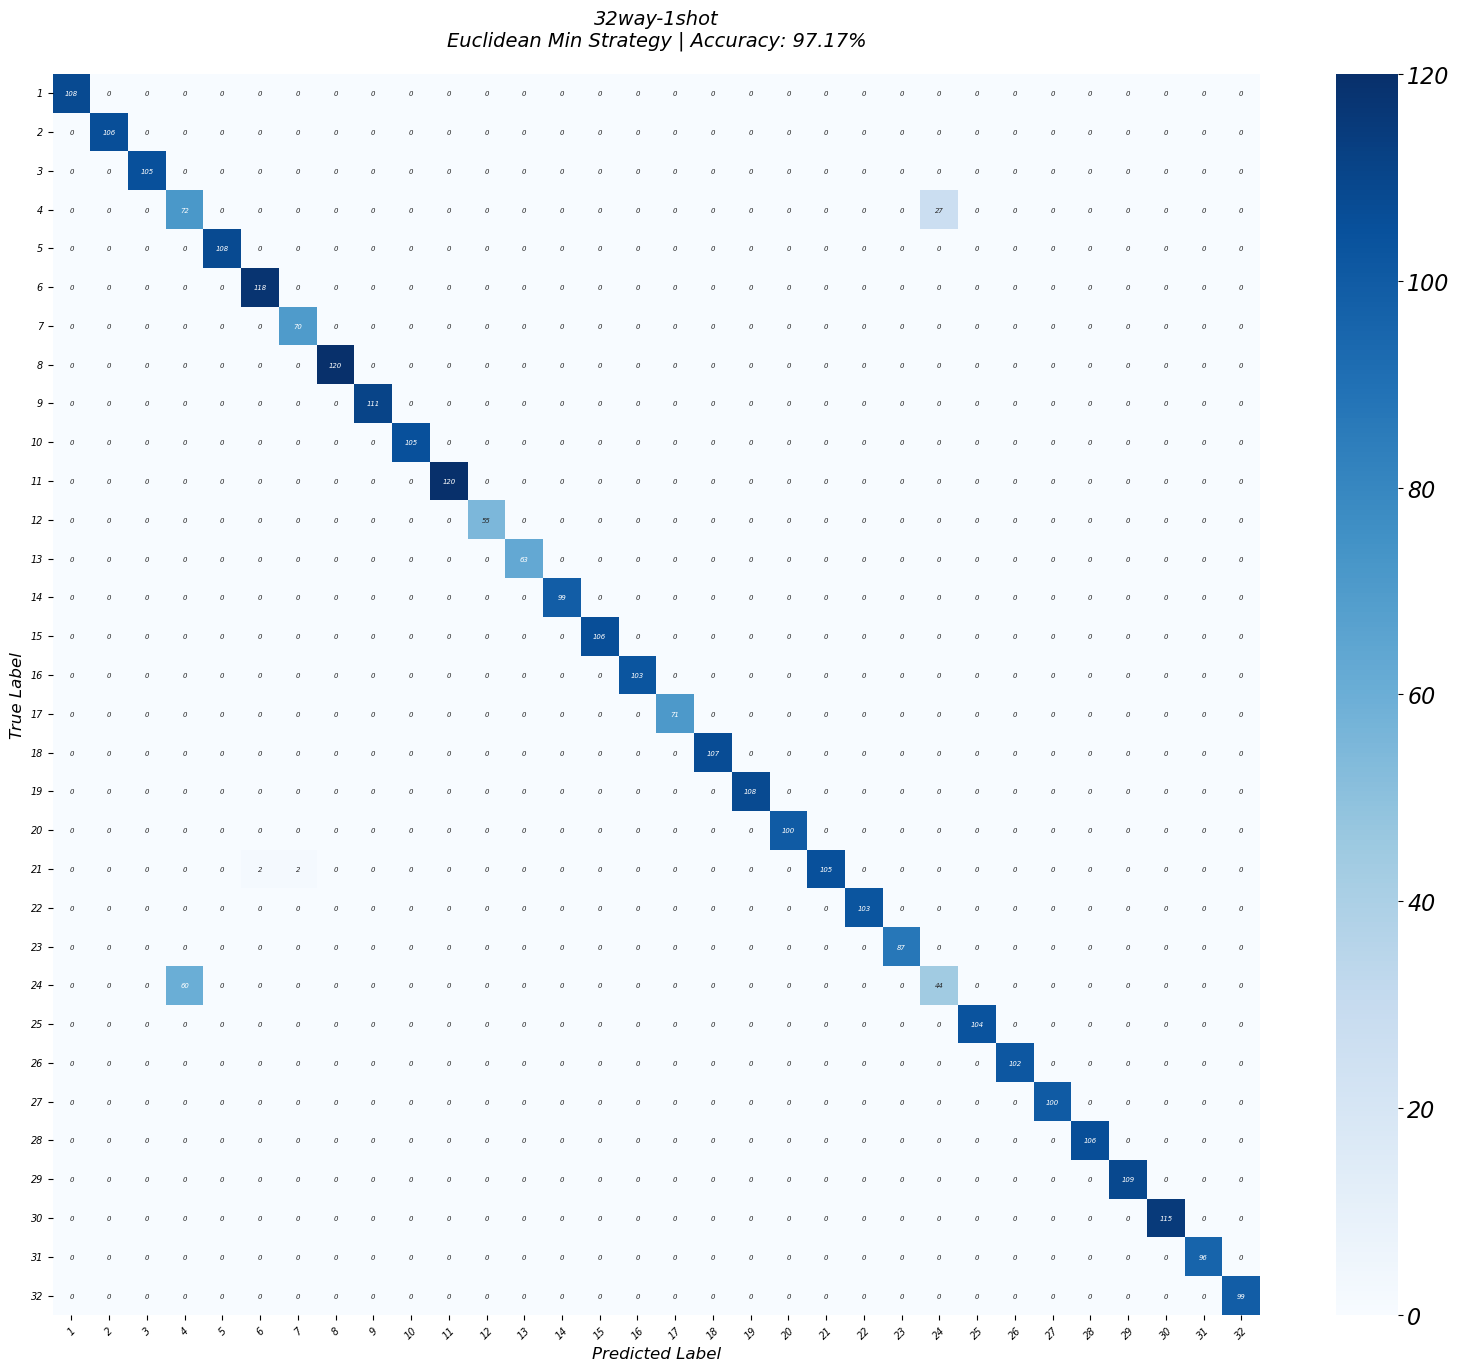

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(16, 14))  # 增大画布适配32分类
cm = confusion_matrix(y_true, y_pred)
class_labels = [str(i+1) for i in range(nnn)]

# 绘制混淆矩阵（移除错误参数，改用正确方式设置刻度字体）
ax = sns.heatmap(cm, 
                 annot=True, 
                 fmt='d', 
                 cmap='Blues', 
                 cbar=True,
                 xticklabels=class_labels,
                 yticklabels=class_labels,
                 annot_kws={'size': 5})  # 进一步减小标注字体

# 正确设置刻度字体大小（修复核心：通过matplotlib的ax对象设置，而非heatmap参数）
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

# 设置坐标轴和标题
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f"32way-1shot\nEuclidean Min Strategy | Accuracy: {acc:.2f}%", fontsize=14, pad=20)

# 可选：旋转x轴标签避免重叠（32分类必备）
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()